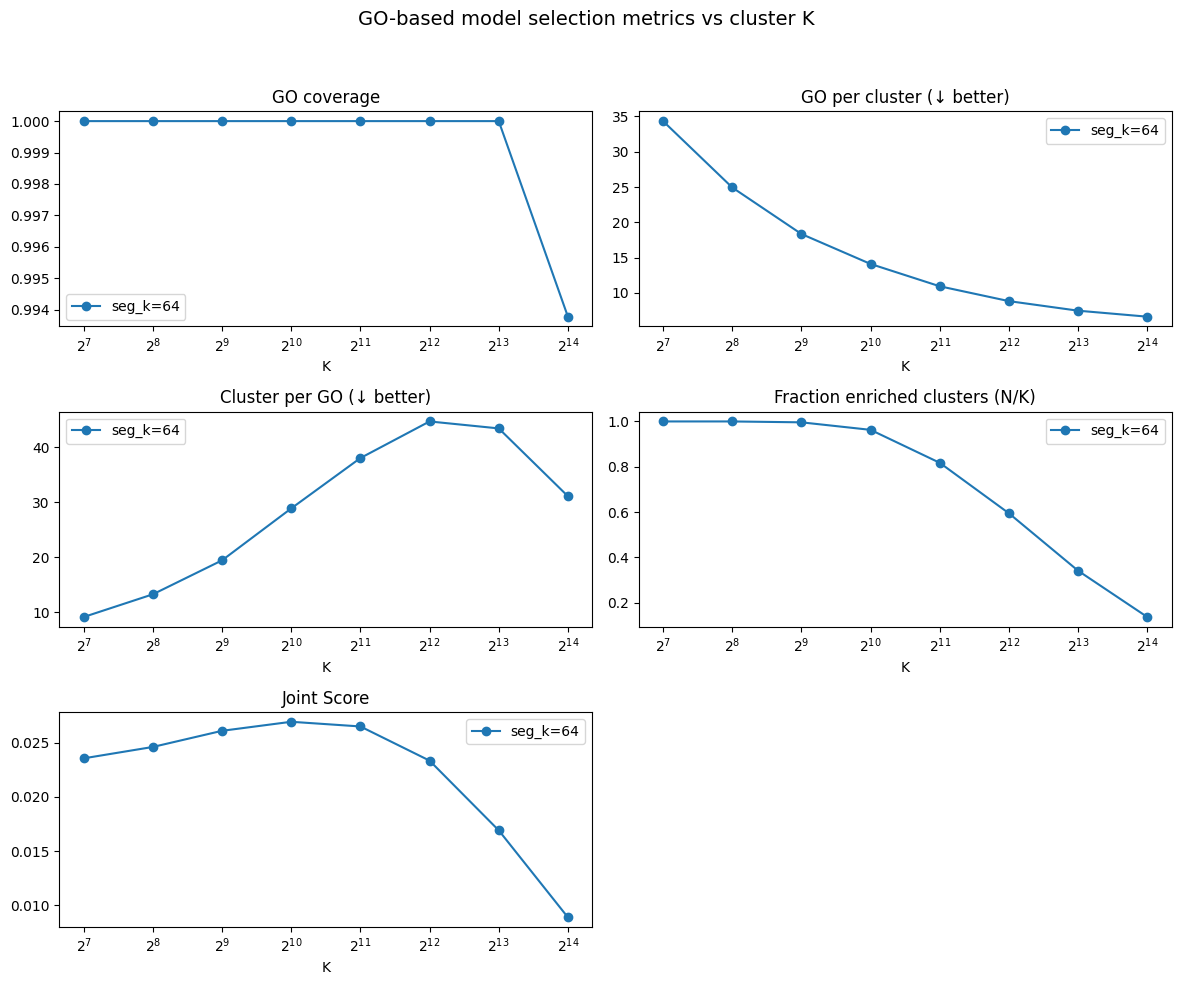

In [ ]:
import matplotlib.pyplot as plt
import analyze_go_enrichment
import os
import json
from collections import defaultdict

csv_dir = "results_13_01/prototypes"
outdir = "go_analysis_13_01"
cluster_ks = [128, 256, 512, 1024, 2048, 4096, 8192, 16384] 
seg_ks = [64]  
Nk, C, S, R, scores = defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list)

for seg_k in seg_ks:
    for K in cluster_ks:
        modelname = f"puffin_K{seg_k}_v4/K{K}"
        outdir_adjusted = os.path.join(outdir, modelname)
        os.makedirs(outdir_adjusted, exist_ok=True)
        metrics = analyze_go_enrichment.get_metrics(
                csv_dir=csv_dir,
                modelname=modelname,
                outdir=outdir_adjusted,
                k=K
            )
        Nk[seg_k].append(metrics['go_per_cluster']['enriched_clusters_fraction'])
        C[seg_k].append(metrics['go_coverage']['coverage_fraction'])
        S[seg_k].append(metrics['go_per_cluster']['mean'])
        R[seg_k].append(metrics['go_specificity']['mean_clusters_per_go'])

        scores[seg_k].append(metrics['focused_go_coverage_score'])

        # -----------------------
        # SAVE METRICS
        # -----------------------
        with open(os.path.join(outdir_adjusted, "metrics.json"), "w") as f:
            json.dump(metrics, f, indent=2)

#Make x axis log scale

fig, axs = plt.subplots(3, 2, figsize=(12, 10))
for ax_row in axs:
    for ax in ax_row:
        ax.set_xscale('log', base=2)
axs = axs.flatten()

# Plot for both seg_ks

for seg_k in seg_ks:
    axs[0].plot(cluster_ks, C[seg_k], marker='o', label=f"seg_k={seg_k}")

axs[0].set_title("GO coverage")
axs[0].set_xlabel("K")
axs[0].legend()

for seg_k in seg_ks:
    axs[1].plot(cluster_ks, S[seg_k], marker='o', label=f"seg_k={seg_k}")
axs[1].set_title("GO per cluster (↓ better)")
axs[1].set_xlabel("K")
axs[1].legend()

for seg_k in seg_ks:
    axs[2].plot(cluster_ks, R[seg_k], marker='o', label=f"seg_k={seg_k}")
axs[2].set_title("Cluster per GO (↓ better)")
axs[2].set_xlabel("K")
axs[2].legend()

for seg_k in seg_ks:
    axs[3].plot(cluster_ks, Nk[seg_k], marker='o', label=f"seg_k={seg_k}")
axs[3].set_title("Fraction enriched clusters (N/K)")
axs[3].set_xlabel("K")
axs[3].legend()

for seg_k in seg_ks:
    axs[4].plot(cluster_ks, scores[seg_k], marker='o', label=f"seg_k={seg_k}")
axs[4].set_title("Joint Score")
axs[4].set_xlabel("K")
axs[4].legend()

axs[5].axis("off")

plt.suptitle("GO-based model selection metrics vs cluster K", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [ ]:
import pandas as pd

# Residue to prototype mapping

def add_residue_to_prototype_mapping(segment_assignments, prototype_assignments):
    pdb_id_segment_to_prototype = {}
    
    for _, row in prototype_assignments.iterrows():
        key = (row['pdb_id'], row['segment_k'])
        pdb_id_segment_to_prototype[key] = row['proto']
    
    out = segment_assignments.copy()

    def parse_and_map(row):
        cluster_ids = [
            int(x.strip())
            for x in row['cluster_ids'].split(',')
            if x.strip() != ''
        ]
        return [
            pdb_id_segment_to_prototype.get((row['pdb_id'], cid))
            for cid in cluster_ids
        ]

    out['protos'] = out.apply(parse_and_map, axis=1)
    return out

In [ ]:
import numpy as np
def get_prototype_per_pdb_id_statistics(segment_assignments_with_protos):
    proto_stats = {
        'mean_unique_prototypes': [],
        'mean_residues_per_prototype': []
    }

    for _, row in segment_assignments_with_protos.iterrows():
        protos = row['protos']

        proto_stats['mean_unique_prototypes'].append(len(set(protos)))
        proto_stats['mean_residues_per_prototype'].append(
            row['n_residues'] / len(set(protos)) if len(set(protos)) > 0 else 0
        )

    means = {
        'mean_unique_prototypes': np.mean(proto_stats['mean_unique_prototypes']),
        'mean_residues_per_prototype': np.mean(proto_stats['mean_residues_per_prototype'])
        }

    return means


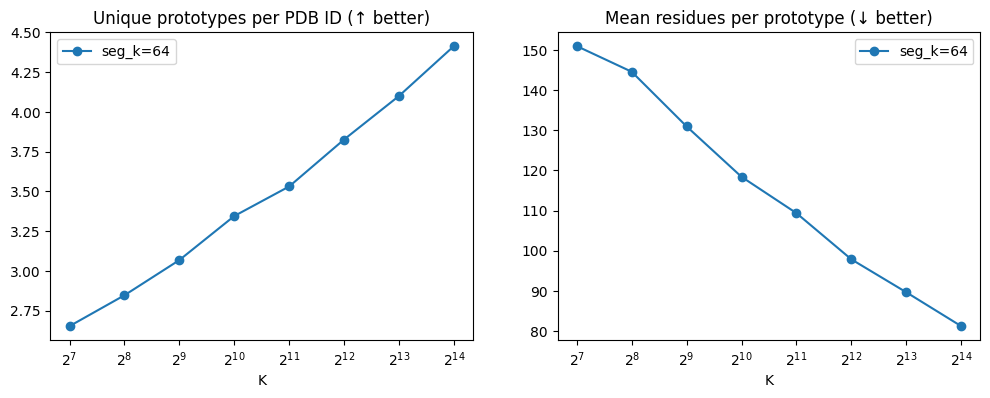

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

segment_assignments = pd.read_csv("results_13_01/segments/puffin_K64_v4/test/test_residue_assignments.csv")

mean_unique_prototypes = defaultdict(list)
mean_residues_per_prototype = defaultdict(list)
seg_ks = [64]
cluster_ks = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]

for seg_k in seg_ks:
    for k in cluster_ks:
        prototype_assignments = pd.read_csv(f"results_13_01/prototypes/puffin_K64_v4/K{k}/assignments_test.csv")
        segment_assignments_with_protos = add_residue_to_prototype_mapping(segment_assignments, prototype_assignments)
        means = get_prototype_per_pdb_id_statistics(segment_assignments_with_protos)
        mean_unique_prototypes[seg_k].append(means['mean_unique_prototypes'])
        mean_residues_per_prototype[seg_k].append(means['mean_residues_per_prototype'])

#Make x axis log scale

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax in axs:
    ax.set_xscale('log', base=2)
axs = axs.flatten()

# Plot for all seg_ks

for seg_k in seg_ks:
    axs[0].plot(cluster_ks, mean_unique_prototypes[seg_k], marker='o', label=f"seg_k={seg_k}")

axs[0].set_title("Unique prototypes per PDB ID (↑ better)")
axs[0].set_xlabel("K")
axs[0].legend()

for seg_k in seg_ks:
    axs[1].plot(cluster_ks, mean_residues_per_prototype[seg_k], marker='o', label=f"seg_k={seg_k}")
axs[1].set_title("Mean residues per prototype (↓ better)")
axs[1].set_xlabel("K")
axs[1].legend()
